In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from copy import copy
from matplotlib.colors import PowerNorm

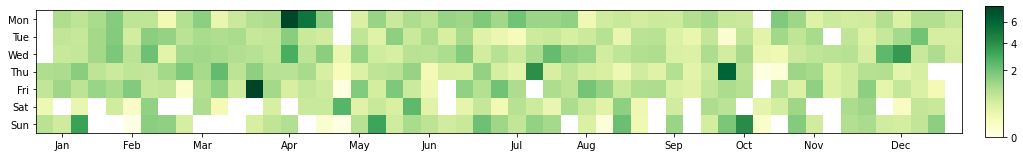

In [5]:
day_matrix = pd.read_csv("./csv/day_matrix.csv", index_col=0)
day_matrix.replace(0, np.nan, inplace=True)

cmap = copy(mpl.cm.get_cmap("YlGn"))
cmap.set_bad(color="white")

plt.rcParams["figure.figsize"] = (20,6)
plt.imshow(day_matrix, cmap=cmap, norm=PowerNorm(gamma=0.5))


ms = pd.date_range(start="2025-01", end="2025-12", freq='MS')
plt.xticks(ms.isocalendar()['week'],ms.strftime('%b'))
plt.yticks(range(7), ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"])
cbar = plt.colorbar(shrink=0.4, pad=0.02, aspect=7)
plt.gcf().set_facecolor("white")

plt.show()

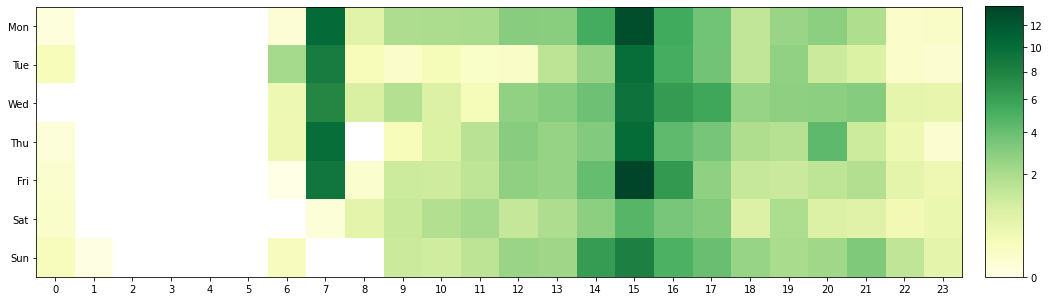

('15', 69.01087166666667)
('Monday', 58.78946583333334)


In [4]:
hour_matrix = pd.read_csv("./csv/hour_matrix.csv", index_col=0)
hour_matrix.replace(0, np.nan, inplace=True)

cmap = copy(mpl.cm.get_cmap("YlGn"))
cmap.set_bad(color="white")

plt.imshow(hour_matrix, cmap=cmap, norm=PowerNorm(gamma=0.5))

plt.xticks(range(24))
plt.yticks(range(7), ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"])
cbar = plt.colorbar(shrink=0.83, pad=0.02, aspect=7)

plt.gcf().set_facecolor("white")
plt.show()

# TODO: move
def max_sum(matrx, axis=0):
  axis_max = matrx.sum(axis=axis).idxmax()
  sum_value = matrx.sum(axis=axis)[axis_max]
  return axis_max, sum_value

print(max_sum(hour_matrix))
print(max_sum(hour_matrix, axis=1))

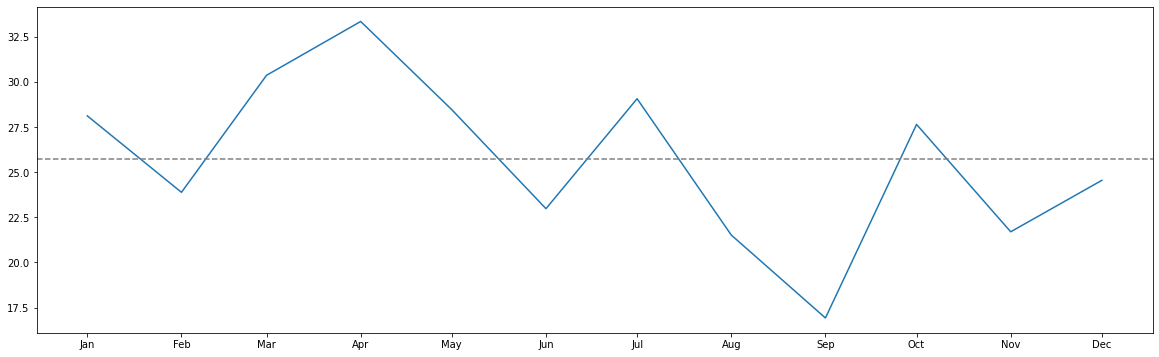

In [6]:
monthy_mins = pd.read_csv("./csv/monthly_stats.csv", index_col=0).reset_index()
monthy_mins['ts'] = pd.to_datetime(monthy_mins['ts'])
monthy_mins = monthy_mins.set_index('ts').sort_index() 
this_year = monthy_mins.loc["2025"]["ms_played"] / 1000 / 60 / 60
last_year = monthy_mins.loc["2024"]["ms_played"] / 1000 / 60 / 60

fig, ax = plt.subplots()
ax.plot(this_year)
# ax.plot(this_year.index, last_year, color='lightblue')
plt.axhline(y=this_year.mean(), color='grey', linestyle='--')

ax.set_xticks(this_year.index, ms.strftime('%b'))
plt.gcf().set_facecolor("white")
plt.show()

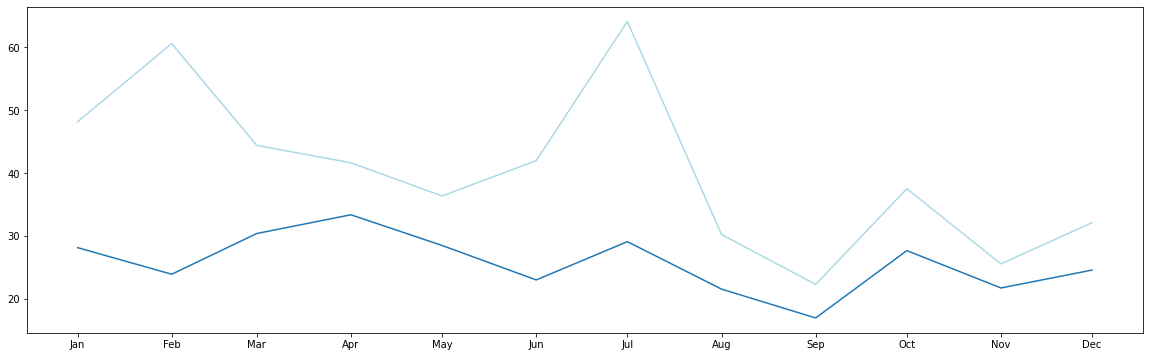

In [12]:
fig, ax = plt.subplots()
ax.plot(this_year)

ax.plot(this_year.index, last_year, color='lightblue')
ax.set_xticks(this_year.index, ms.strftime('%b'))
plt.gcf().set_facecolor("white")
plt.show()

In [13]:
ms = monthy_mins.loc["2025"]["ms_played"].sum()
h = ms / 1000 / 60 / 60

arr = [("billion ms", ms / 1e9), ("hours", h), ("days", h / 24)]
arr.append(("avg min/d", h * 60 / 365))
arr.append(("IGOR streams", ms / 1000 / 2734))
arr.append(("LOTR extended trilogies", ms / 1000 / 40920))
arr.append(("Wicked musicals", h / 2.5))
arr.append(("Ocean Man streams", ms / 1000 / 127))
arr.append(("TS album discography", h * 60 / 996)) # taylor swift first 12 albums (incl. tv, no duplicates)
arr

[('billion ms', 1.110684056),
 ('hours', 308.5233488888889),
 ('days', 12.855139537037038),
 ('avg min/d', 50.71616694063927),
 ('IGOR streams', 406.24874030724214),
 ('LOTR extended trilogies', 27.142816617790814),
 ('Wicked musicals', 123.40933955555556),
 ('Ocean Man streams', 8745.543748031498),
 ('TS album discography', 18.58574390896921)]

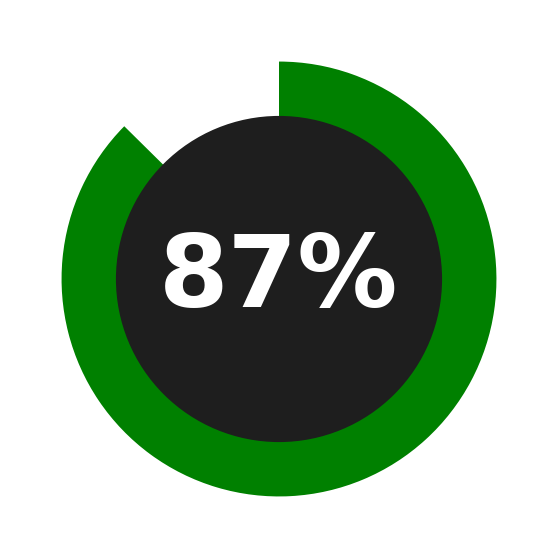

319

In [8]:
days_streamed = 365 - ( day_matrix.isna().sum().sum() + 6 ) # jan 1 and dec 31, 2025 were wednesdays
days_pc = days_streamed / 365

fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot(1,1,1)

pie = ax.pie([days_pc, 1 - days_pc], colors='green', startangle=90, counterclock=False)
pie[0][1].set_alpha(0)

fig.gca().add_artist(plt.Circle((0, 0), 0.75, fc='#1e1e1e'))

# fontsize=80, :.1f if I wanted one decimal place... or lose the % and run up the fontsize (144+)
ax.text(0,0, "{:.0f}%".format(days_pc * 100), horizontalalignment='center', 
        verticalalignment='center', fontsize=100, fontweight='bold', color='white')

plt.show()
days_streamed

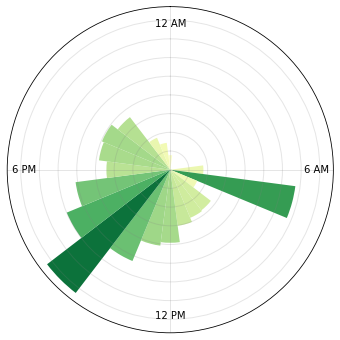

In [73]:
theta = np.linspace(0.0, 2 * np.pi, 24, endpoint=False)
radii = np.sqrt(hour_matrix.sum())
width = np.pi / 12
colors = plt.cm.YlGn(radii / 10)

ax = plt.subplot(projection='polar')
ax.set_yticklabels([])
ax.set_theta_zero_location('N') 
ax.bar(theta, radii, width=width, bottom=0.0, color=colors)
plt.grid(color='gray', linestyle='-', linewidth=1, alpha=0.2)

ticks = np.linspace(0, 2*np.pi, 4, endpoint=False)
ax.set_xticks(ticks, colors="red")
ax.set_xticklabels(["12 AM", "6 AM", "12 PM", "6 PM"])
ax.tick_params(axis="x",direction="in", pad=-24)

ax.set_theta_direction(-1) 

plt.show()